# EEG prior / reconstruction experiments

This report documents the maintained prior-only and joint EEG alignment + diffusion-prior experiments. Both use the simplified repository reconstruction path, so these results are not direct reproductions of the EEG-Guided Diffusion paper.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RUNS = {
    'Prior-only': PROJECT_ROOT / 'experiments/eeg_prior/20260831_134809/train_eeg-20260831_134844/version_0',
    'Joint alignment + prior': PROJECT_ROOT / 'experiments/eeg_alignprior/20260904_100813/train_eeg-20260904_100911/version_0',
}
for path in RUNS.values():
    assert (path / 'test/test_metrics.csv').exists(), path
print('Found saved artifacts for:', ', '.join(RUNS))

Found saved artifacts for: Prior-only, Joint alignment + prior


## Protocols

| Component | Prior-only | Joint alignment + prior |
|---|---|---|
| Training mode | `do_align=false`, `do_recon=true` | `do_align=true`, `do_recon=true` |
| EEG initialization | Finished alignment checkpoint | Finished alignment checkpoint |
| Alignment target | — | `aligned_synclr_vitb16` |
| Alignment loss | — | Pure symmetric InfoNCE; no MSE or augmentation |
| Prior target | `clip_vith14` image latent | `clip_vith14` image latent |
| Trainable modules | EEG encoder and diffusion prior | EEG encoder and diffusion prior |
| Batch / workers | 32 / 4 | 32 / 4 |
| Checkpoint selection | Maximum `eval/val/prior/pred_cos` | Maximum `eval/val/prior/pred_cos` |

Training writes TensorBoard events. The separate evaluator writes `test_metrics.csv`, `evaluation_config.yaml`, and reconstruction/ground-truth image pairs.

In [2]:
def load_metrics(run_dir):
    frame = pd.read_csv(run_dir / 'test/test_metrics.csv')
    frame['metric'] = frame['metric'].str.replace('eval/test/prior/recon/', '', regex=False)
    frame['metric'] = frame['metric'].str.replace('eval/test/prior/pred_cos', 'prior_cosine', regex=False)
    return frame.set_index('metric')['value']

results = pd.DataFrame({name: load_metrics(path) for name, path in RUNS.items()}).T
results = results.rename(columns={
    'prior_cosine': 'Prior cosine', 'pixcorr': 'PixCorr', 'ssim': 'SSIM',
    'alex2': 'AlexNet-2', 'alex5': 'AlexNet-5', 'inceptionv3': 'Inception',
    'clip': 'CLIP', 'efficientnet': 'EfficientNet', 'swav': 'SwAV',
    'eval/test/align/brain_acc': 'Alignment brain_acc',
    'eval/test/align/image_acc': 'Alignment image_acc',
    'eval/test/align/sim': 'Alignment similarity',
})
display(results.round(5))
assert results.loc['Joint alignment + prior', 'Prior cosine'] == 0.6419938802719116

metric,AlexNet-2,AlexNet-5,CLIP,EfficientNet,Alignment brain_acc,Alignment image_acc,Alignment similarity,Inception,PixCorr,Prior cosine,SSIM,SwAV
Prior-only,0.72222,0.88889,0.79167,0.90044,NaN,NaN,NaN,0.63889,0.09722,0.63396,0.30855,0.58795
Joint alignment + prior,0.94444,0.91667,0.84722,0.89120,0.595,0.515,0.26422,0.80556,0.18108,0.64199,0.31573,0.56445


## Joint-run result

The joint run selected `epoch_0409-eval_val_prior_pred_cos_0.6420.ckpt`. On the 200-image test split it achieved prior cosine `0.6420`, PixCorr `0.1811`, SSIM `0.3157`, and alignment `image_acc=0.515` (`brain_acc=0.595`). Alignment metrics measure retrieval in the aligned SynCLR space; prior metrics measure the generated reconstruction path.

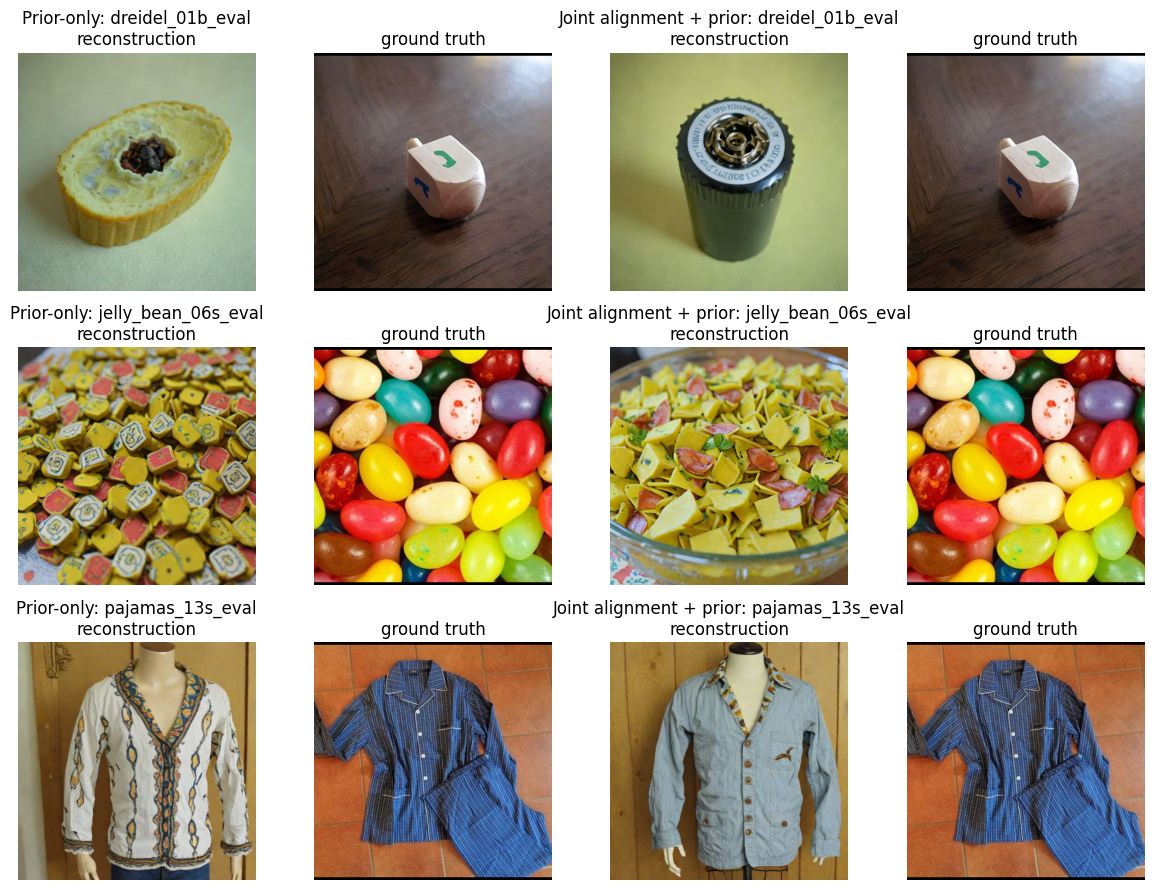

In [3]:
def reconstruction_pairs(run_dir):
    pairs = []
    for recon_path in sorted((run_dir / 'test').glob('*/test/prior/recon.png')):
        gt_path = recon_path.with_name('gt.png')
        if gt_path.exists():
            pairs.append((recon_path.parent.parent.parent.name, recon_path, gt_path))
    return pairs

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, (name, run_dir) in enumerate(RUNS.items()):
    pairs = reconstruction_pairs(run_dir)
    assert len(pairs) >= 3, (name, len(pairs))
    for col, (label, recon_path, gt_path) in enumerate(pairs[:3]):
        axes[col, row * 2].imshow(Image.open(recon_path))
        axes[col, row * 2].set_title(f'{name}: {label}\nreconstruction')
        axes[col, row * 2].axis('off')
        axes[col, row * 2 + 1].imshow(Image.open(gt_path))
        axes[col, row * 2 + 1].set_title('ground truth')
        axes[col, row * 2 + 1].axis('off')
plt.tight_layout()
plt.show()

## Conclusion

The prior-only and joint experiments are now recorded with their exact checkpoints and evaluation artifacts. The joint run tests whether simultaneous EEG alignment improves diffusion-prior reconstruction; this report records the measured outcome without claiming paper-level parity.